# **NAIVE BAYES CLASSIFICATION - UTS MACHINE LEARNING**
## **Prediksi Gaji Karyawan PT XYZ**

**Nama**: Sistra Amanda Singa                                                                         
**NIM**: 4222301011                                                                            
**Institusi**: Polibatam                                                                             
**Mata Kuliah**: Machine Learning  
**Topik**: Naive Bayes Classification  
**Waktu**: 2026



## **BAGIAN A: TEORI DAN KONSEP**
---

### 1. Definisi Naive Bayes

**Naive Bayes** adalah algoritma klasifikasi probabilistik yang berbasis pada Teorema Bayes. Algoritma ini sangat populer dalam machine learning karena:
- Sederhana dan mudah dipahami
- Cepat dalam training dan prediksi
- Efektif untuk dataset berdimensi tinggi
- Cocok untuk klasifikasi multi-class

### 2. Teorema Bayes

Teorema Bayes adalah formula probabilitas bersyarat yang dinyatakan sebagai:

$$P(C|X) = \frac{P(X|C) \times P(C)}{P(X)}$$

Dimana:
1. **P(C|X)** = Posterior Probability (probabilitas class C diberikan fitur X)
2. **P(X|C)** = Likelihood (probabilitas fitur X diberikan class C)
3. **P(C)** = Prior Probability (probabilitas class C sebelum melihat data)
4. **P(X)** = Evidence/Marginal Probability (probabilitas fitur X di seluruh data)

### 3. Asumsi "Naive"

Asumsi naïve dari algoritma ini adalah semua atribut/fitur bersifat **independen secara kondisional** terhadap target class:

$$P(X|C) = P(X_1|C) \times P(X_2|C) \times ... \times P(X_n|C)$$

Meskipun asumsi ini sering tidak berlaku di dunia nyata, Naive Bayes tetap memberikan hasil yang baik pada banyak aplikasi praktis.

### 4. Varian Naive Bayes

#### a) Gaussian Naive Bayes
Mengasumsikan distribusi Gaussian (normal) untuk fitur numerik:

$$P(X_i|C) = \frac{1}{\sqrt{2\pi\sigma_C^2}} \exp\left(-\frac{(X_i - \mu_C)^2}{2\sigma_C^2}\right)$$

#### b) Multinomial Naive Bayes
Untuk fitur yang merepresentasikan count atau frequency (misalnya: text classification).

#### c) Categorical Naive Bayes
Untuk fitur kategorikal dengan multiple categories.

**Dalam praktik ini, kami menggunakan Gaussian Naive Bayes karena dataset kami memiliki campuran fitur numerik dan kategorik.**

### 5. Langkah-langkah Klasifikasi

1. **Hitung Prior Probability**: P(C) untuk setiap class
2. **Hitung Likelihood**: P(X|C) untuk setiap fitur
3. **Hitung Posterior**: Gunakan Bayes theorem untuk setiap class
4. **Prediksi**: Pilih class dengan posterior probability tertinggi

### 6. Kelebihan dan Kelemahan

**Kelebihan:**
1. Cepat dan efisien (O(n))
2. Bekerja baik dengan high-dimensional data
3.  Cocok untuk real-time prediction
4.  Membutuhkan data training yang relatif sedikit
5.  Tidak sensitif terhadap fitur yang tidak relevan (irrelevant features)

**Kelemahan:**
1.  Asumsi independensi sering tidak berlaku
2.  Zero-frequency problem (jika ada kombinasi fitur yang tidak muncul)
3.  Tidak akurat untuk dataset yang sangat imbalanced
4.  Estimasi probability kurang akurat jika data sedikit
5.  Kurang performa dibanding algoritma lebih kompleks untuk task tertentu

### 7. Aplikasi Naive Bayes di Dunia Nyata

1.  **Email Spam Detection** - Klasifikasi email sebagai spam atau tidak
2.  **Sentiment Analysis** - Analisis sentimen teks (positif/negatif)
3.  **Text Classification** - Kategorisasi dokumen otomatis
4.  **Content Recommendation** - Rekomendasi konten berdasarkan preferensi
5.  **Disease Diagnosis** - Prediksi diagnosis penyakit berdasarkan gejala
6.  **HR Analytics** - Prediksi gaji seperti pada kasus ini


---
## BAGIAN B: PRAKTIK (CODE)
---

### Import Library

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("✓ Semua library berhasil diimport")

✓ Semua library berhasil diimport


### 1. Loading Data

In [22]:
# Load dataset
df = pd.read_csv('dataset_karyawan_missing.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData Info:")
print(df.info())
print(f"\nStatistik Deskriptif:")
print(df.describe())

Dataset Shape: (200, 7)

First 5 rows:
   ID   Nama Departemen       Gaji  Usia  Lama_Kerja Status_Karyawan
0   1  Citra        NaN  5744870.0    53           9         Kontrak
1   2    Eka        HRD  5862014.0    39           9           Tetap
2   3  Citra        HRD  4894992.0    55          16           Tetap
3   4   Budi         QC  4606286.0    51           2         Kontrak
4   5   Dewi        HRD  4199766.0    44           7         Kontrak

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               200 non-null    int64  
 1   Nama             200 non-null    str    
 2   Departemen       190 non-null    str    
 3   Gaji             190 non-null    float64
 4   Usia             200 non-null    int64  
 5   Lama_Kerja       200 non-null    int64  
 6   Status_Karyawan  200 non-null    str    
dtypes: float64(1), int64(3)

### 2. Exploratory Data Analysis (EDA)

In [23]:
# Cek missing values
print("Missing Values:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])
print(f"\nPersentase Missing:")
print((missing_data[missing_data > 0] / len(df) * 100).round(2))

# Unique values
print(f"\nUnique Values:")
print(f"Departemen: {df['Departemen'].nunique()} - {df['Departemen'].unique()}")
print(f"Status Karyawan: {df['Status_Karyawan'].nunique()} - {df['Status_Karyawan'].unique()}")
print(f"Range Gaji: Rp {df['Gaji'].min():,.0f} - Rp {df['Gaji'].max():,.0f}")
print(f"Range Usia: {df['Usia'].min()} - {df['Usia'].max()} tahun")
print(f"Range Lama Kerja: {df['Lama_Kerja'].min()} - {df['Lama_Kerja'].max()} tahun")

Missing Values:
Departemen    10
Gaji          10
dtype: int64

Persentase Missing:
Departemen    5.0
Gaji          5.0
dtype: float64

Unique Values:
Departemen: 4 - <StringArray>
[nan, 'HRD', 'QC', 'Produksi', 'Logistik']
Length: 5, dtype: str
Status Karyawan: 2 - <StringArray>
['Kontrak', 'Tetap']
Length: 2, dtype: str
Range Gaji: Rp 2,786,682 - Rp 6,941,904
Range Usia: 22 - 59 tahun
Range Lama Kerja: 0 - 29 tahun


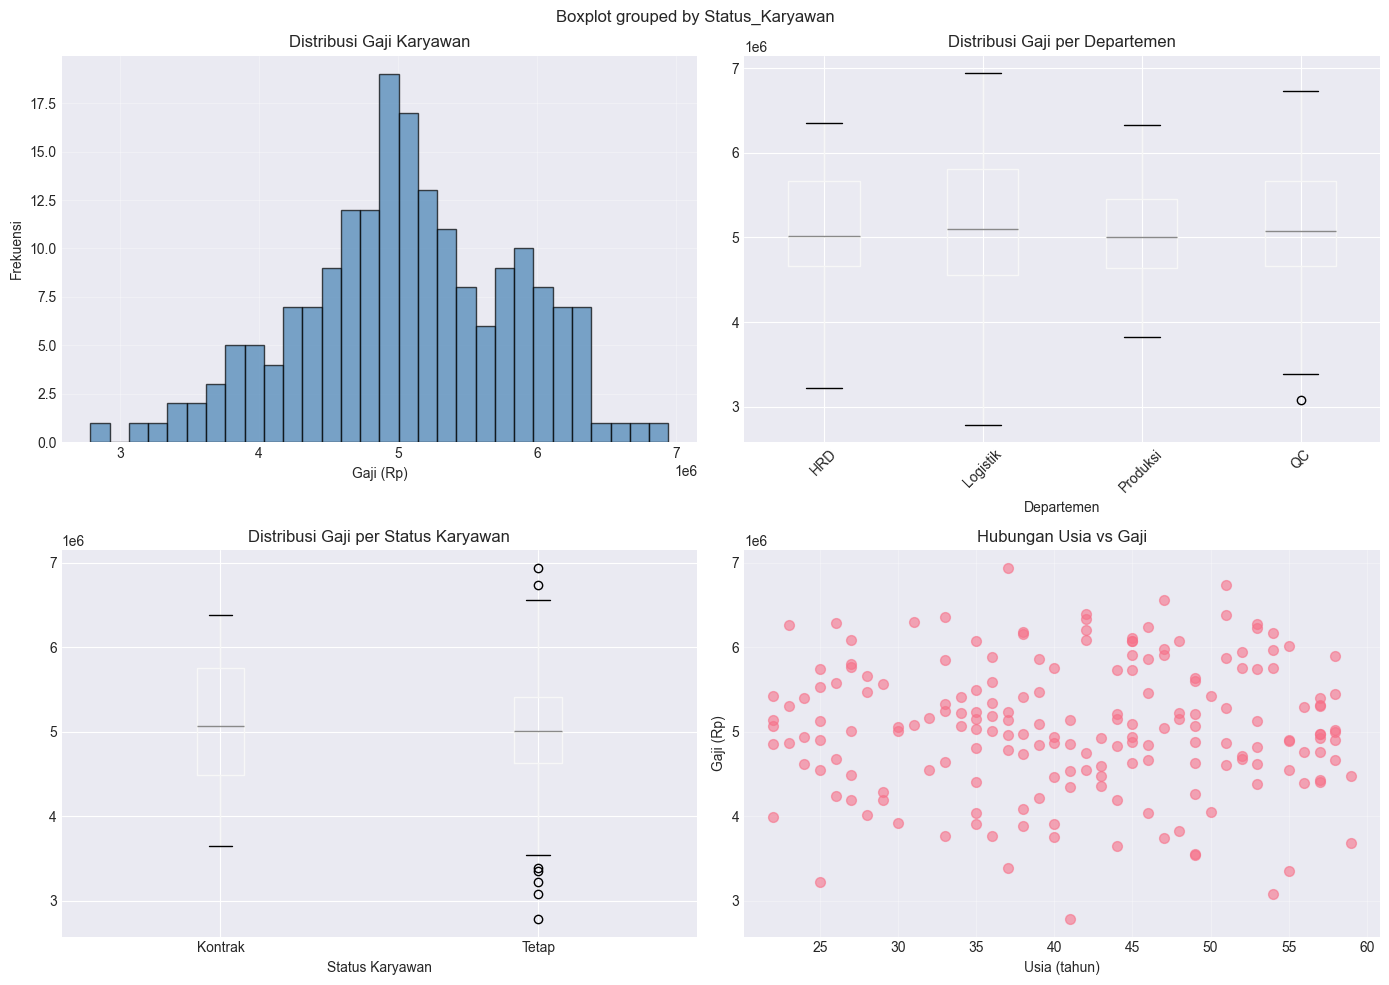

In [24]:
# Visualisasi distribusi gaji
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram gaji
axes[0, 0].hist(df['Gaji'].dropna(), bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Gaji (Rp)')
axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].set_title('Distribusi Gaji Karyawan')
axes[0, 0].grid(alpha=0.3)

# Gaji by Departemen
df.boxplot(column='Gaji', by='Departemen', ax=axes[0, 1])
axes[0, 1].set_title('Distribusi Gaji per Departemen')
axes[0, 1].set_xlabel('Departemen')
plt.sca(axes[0, 1])
plt.xticks(rotation=45)

# Gaji by Status
df.boxplot(column='Gaji', by='Status_Karyawan', ax=axes[1, 0])
axes[1, 0].set_title('Distribusi Gaji per Status Karyawan')
axes[1, 0].set_xlabel('Status Karyawan')

# Scatter Usia vs Gaji
axes[1, 1].scatter(df['Usia'], df['Gaji'], alpha=0.6, s=50)
axes[1, 1].set_xlabel('Usia (tahun)')
axes[1, 1].set_ylabel('Gaji (Rp)')
axes[1, 1].set_title('Hubungan Usia vs Gaji')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Data Preprocessing

In [25]:
# Buat copy untuk preprocessing
df_processed = df.copy()

# Handle missing values
print("[HANDLING MISSING VALUES]")

# Missing Departemen: isi dengan mode (nilai terbanyak)
mode_dept = df_processed['Departemen'].mode()[0]
df_processed['Departemen'].fillna(mode_dept, inplace=True)
print(f"Departemen missing: diisi dengan mode '{mode_dept}'")

# Missing Gaji: isi dengan median
median_gaji = df_processed['Gaji'].median()
df_processed['Gaji'].fillna(median_gaji, inplace=True)
print(f"Gaji missing: diisi dengan median Rp {median_gaji:,.0f}")

# Verifikasi
print(f"\nMissing values setelah handling:")
print(df_processed.isnull().sum())

[HANDLING MISSING VALUES]
Departemen missing: diisi dengan mode 'HRD'
Gaji missing: diisi dengan median Rp 5,040,414

Missing values setelah handling:
ID                  0
Nama                0
Departemen         10
Gaji               10
Usia                0
Lama_Kerja          0
Status_Karyawan     0
dtype: int64


In [26]:
# Kategorisasi Gaji menjadi 3 kategori (Target Variable)
print("\n[KATEGORISASI GAJI]")

# Gunakan kuartil untuk membagi kategori
Q1 = df_processed['Gaji'].quantile(0.33)
Q2 = df_processed['Gaji'].quantile(0.67)

def kategorikan_gaji(gaji):
    if gaji < Q1:
        return 'Rendah'
    elif gaji < Q2:
        return 'Sedang'
    else:
        return 'Tinggi'

df_processed['Kategori_Gaji'] = df_processed['Gaji'].apply(kategorikan_gaji)

print(f"Batas Kategori:")
print(f"  Rendah: < Rp {Q1:,.0f}")
print(f"  Sedang: Rp {Q1:,.0f} - Rp {Q2:,.0f}")
print(f"  Tinggi: > Rp {Q2:,.0f}")

print(f"\nDistribusi Kategori Gaji:")
print(df_processed['Kategori_Gaji'].value_counts())
print(f"\nProporsi:")
print(df_processed['Kategori_Gaji'].value_counts(normalize=True).round(3))


[KATEGORISASI GAJI]
Batas Kategori:
  Rendah: < Rp 4,769,188
  Sedang: Rp 4,769,188 - Rp 5,379,417
  Tinggi: > Rp 5,379,417

Distribusi Kategori Gaji:
Kategori_Gaji
Tinggi    73
Sedang    64
Rendah    63
Name: count, dtype: int64

Proporsi:
Kategori_Gaji
Tinggi    0.365
Sedang    0.320
Rendah    0.315
Name: proportion, dtype: float64


### 4. Feature Engineering & Encoding

In [27]:
# Pilih fitur
fitur_numerik = ['Usia', 'Lama_Kerja']
fitur_kategorik = ['Departemen', 'Status_Karyawan']

X = df_processed[fitur_numerik + fitur_kategorik].copy()
y = df_processed['Kategori_Gaji'].copy()

print("Fitur yang digunakan:")
print(f"  Numerik: {fitur_numerik}")
print(f"  Kategorik: {fitur_kategorik}")

# Encoding variabel kategorik
label_encoders = {}

print("\n[LABEL ENCODING]")
for col in fitur_kategorik:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"\n{col}:")
    for i, label in enumerate(le.classes_):
        print(f"  {label} → {i}")

print("\nMatriks Fitur (X) setelah encoding:")
print(X.head(10))

Fitur yang digunakan:
  Numerik: ['Usia', 'Lama_Kerja']
  Kategorik: ['Departemen', 'Status_Karyawan']

[LABEL ENCODING]

Departemen:
  HRD → 0
  Logistik → 1
  Produksi → 2
  QC → 3
  nan → 4

Status_Karyawan:
  Kontrak → 0
  Tetap → 1

Matriks Fitur (X) setelah encoding:
   Usia  Lama_Kerja  Departemen  Status_Karyawan
0    53           9           4                0
1    39           9           0                1
2    55          16           0                1
3    51           2           3                0
4    44           7           0                0
5    41          22           2                0
6    44          16           3                0
7    29          19           2                0
8    35           6           4                1
9    44          20           1                1


### 5. Train-Test Split

In [28]:
# Split data dengan stratification untuk mempertahankan proporsi kelas
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Ukuran Training Set: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Ukuran Testing Set: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nDistribusi Kelas Training:")
print(y_train.value_counts())

print(f"\nDistribusi Kelas Testing:")
print(y_test.value_counts())

Ukuran Training Set: 160 (80.0%)
Ukuran Testing Set: 40 (20.0%)

Distribusi Kelas Training:
Kategori_Gaji
Tinggi    59
Sedang    51
Rendah    50
Name: count, dtype: int64

Distribusi Kelas Testing:
Kategori_Gaji
Tinggi    14
Rendah    13
Sedang    13
Name: count, dtype: int64


### 6. Training Naïve Bayes Model

In [29]:
# Training Gaussian Naïve Bayes
print("[TRAINING GAUSSIAN NAÏVE BAYES]\n")

model = GaussianNB()
model.fit(X_train, y_train)

print("✓ Model berhasil dilatih\n")

# Tampilkan parameter model
print("Classes:", model.classes_)

print("\nPrior Probability (P(C)):")
for i, class_name in enumerate(model.classes_):
    print(f"  P({class_name}) = {model.class_prior_[i]:.4f}")

feature_names = fitur_numerik + fitur_kategorik

print("\nMean per Kelas (μ):")
for i, class_name in enumerate(model.classes_):
    print(f"\n  {class_name}:")
    for j, feat_name in enumerate(feature_names):
        print(f"    μ({feat_name}) = {model.theta_[i, j]:.4f}")

print("\nVariance per Kelas (σ²):")
for i, class_name in enumerate(model.classes_):
    print(f"\n  {class_name}:")
    for j, feat_name in enumerate(feature_names):
        print(f"    σ²({feat_name}) = {model.var_[i, j]:.4f}")

[TRAINING GAUSSIAN NAÏVE BAYES]

✓ Model berhasil dilatih

Classes: ['Rendah' 'Sedang' 'Tinggi']

Prior Probability (P(C)):
  P(Rendah) = 0.3125
  P(Sedang) = 0.3187
  P(Tinggi) = 0.3688

Mean per Kelas (μ):

  Rendah:
    μ(Usia) = 43.3400
    μ(Lama_Kerja) = 14.7800
    μ(Departemen) = 1.7400
    μ(Status_Karyawan) = 0.4400

  Sedang:
    μ(Usia) = 41.0196
    μ(Lama_Kerja) = 12.5686
    μ(Departemen) = 1.5294
    μ(Status_Karyawan) = 0.5882

  Tinggi:
    μ(Usia) = 40.5932
    μ(Lama_Kerja) = 15.9322
    μ(Departemen) = 1.4407
    μ(Status_Karyawan) = 0.4576

Variance per Kelas (σ²):

  Rendah:
    σ²(Usia) = 111.4644
    σ²(Lama_Kerja) = 63.7316
    σ²(Departemen) = 1.7924
    σ²(Status_Karyawan) = 0.2464

  Sedang:
    σ²(Usia) = 120.6075
    σ²(Lama_Kerja) = 58.6767
    σ²(Departemen) = 1.5825
    σ²(Status_Karyawan) = 0.2422

  Tinggi:
    σ²(Usia) = 96.5464
    σ²(Lama_Kerja) = 77.0463
    σ²(Departemen) = 1.5007
    σ²(Status_Karyawan) = 0.2482


### 7. Prediksi & Evaluasi

In [30]:
# Prediksi
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

print("[PREDIKSI HASIL]\n")
print(f"Jumlah sampel di test set: {len(y_test)}")
print(f"\nComparison True vs Predicted:")

# Tampilkan beberapa contoh prediksi
comparison_df = pd.DataFrame({
    'True': y_test.values[:15],
    'Predicted': y_pred[:15],
    'Correct': (y_test.values[:15] == y_pred[:15])
})
print(comparison_df)

[PREDIKSI HASIL]

Jumlah sampel di test set: 40

Comparison True vs Predicted:
      True Predicted  Correct
0   Rendah    Rendah     True
1   Sedang    Tinggi    False
2   Rendah    Sedang    False
3   Sedang    Tinggi    False
4   Tinggi    Tinggi     True
5   Tinggi    Tinggi     True
6   Tinggi    Tinggi     True
7   Tinggi    Sedang    False
8   Tinggi    Tinggi     True
9   Tinggi    Rendah    False
10  Rendah    Tinggi    False
11  Sedang    Sedang     True
12  Rendah    Sedang    False
13  Tinggi    Rendah    False
14  Sedang    Tinggi    False


In [31]:
# Evaluasi Model
print("\n[EVALUASI MODEL]\n")

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred))


[EVALUASI MODEL]

Accuracy: 0.3250 (32.50%)
Precision (weighted): 0.3367
Recall (weighted): 0.3250
F1-Score (weighted): 0.3139

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Rendah       0.38      0.23      0.29        13
      Sedang       0.33      0.23      0.27        13
      Tinggi       0.30      0.50      0.38        14

    accuracy                           0.33        40
   macro avg       0.34      0.32      0.31        40
weighted avg       0.34      0.33      0.31        40



### 8. Confusion Matrix

Confusion Matrix:
[[3 3 7]
 [1 3 9]
 [4 3 7]]

True Positives per Class:
  Rendah: 3
  Sedang: 3
  Tinggi: 7


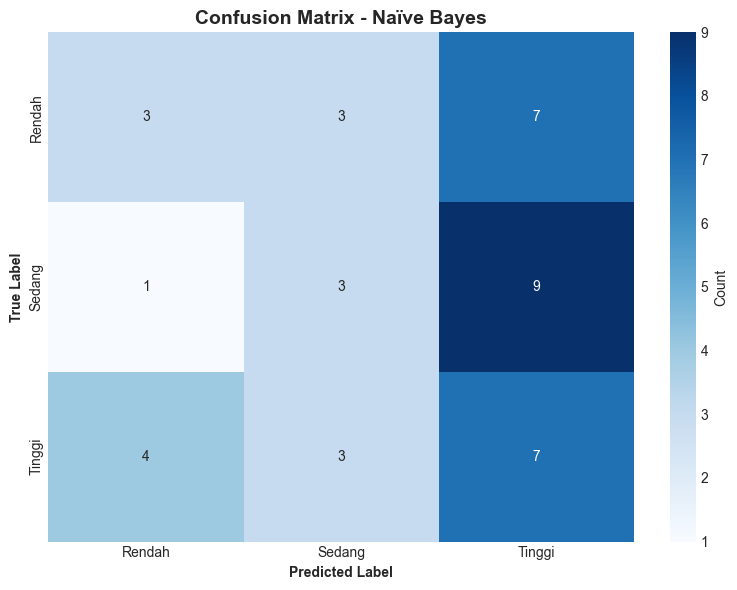

In [32]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

print("Confusion Matrix:")
print(cm)
print(f"\nTrue Positives per Class:")
for i, class_name in enumerate(model.classes_):
    print(f"  {class_name}: {cm[i, i]}")

# Visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Naïve Bayes', fontweight='bold', fontsize=14)
plt.ylabel('True Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.tight_layout()
plt.show()

### 9. Analisis Probability Prediksi

In [33]:
# Tampilkan prediksi dengan probability
print("Contoh Prediksi dengan Confidence Score:\n")
print(f"{'No':<4} {'True':<8} {'Predicted':<10} {'Confidence':<12} {'Probabilities'}")
print("-" * 80)

for i in range(min(10, len(y_test))):
    true_class = y_test.iloc[i]
    pred_class = y_pred[i]
    confidence = np.max(y_pred_proba[i])
    probs = [f"{p:.3f}" for p in y_pred_proba[i]]
    
    status = "✓" if true_class == pred_class else "✗"
    print(f"{i+1:<4} {true_class:<8} {pred_class:<10} {confidence:<12.4f} {probs}")

Contoh Prediksi dengan Confidence Score:

No   True     Predicted  Confidence   Probabilities
--------------------------------------------------------------------------------
1    Rendah   Rendah     0.3699       ['0.370', '0.302', '0.328']
2    Sedang   Tinggi     0.3993       ['0.288', '0.313', '0.399']
3    Rendah   Sedang     0.4819       ['0.180', '0.482', '0.339']
4    Sedang   Tinggi     0.4678       ['0.344', '0.188', '0.468']
5    Tinggi   Tinggi     0.3575       ['0.329', '0.313', '0.358']
6    Tinggi   Tinggi     0.4517       ['0.297', '0.251', '0.452']
7    Tinggi   Tinggi     0.5853       ['0.298', '0.117', '0.585']
8    Tinggi   Sedang     0.4212       ['0.369', '0.421', '0.210']
9    Tinggi   Tinggi     0.5684       ['0.304', '0.127', '0.568']
10   Tinggi   Rendah     0.5035       ['0.503', '0.199', '0.297']


### 10. Prediksi untuk Data Baru

In [34]:
# Prediksi untuk data karyawan baru
print("[PREDIKSI DATA KARYAWAN BARU]\n")

# Buat data baru
new_employees = pd.DataFrame({
    'Usia': [28, 45, 52],
    'Lama_Kerja': [2, 15, 20],
    'Departemen': ['HRD', 'Produksi', 'Logistik'],
    'Status_Karyawan': ['Kontrak', 'Tetap', 'Tetap']
})

print("Data Karyawan Baru:")
print(new_employees)

# Encoding
new_employees_encoded = new_employees.copy()
new_employees_encoded['Departemen'] = label_encoders['Departemen'].transform(new_employees_encoded['Departemen'])
new_employees_encoded['Status_Karyawan'] = label_encoders['Status_Karyawan'].transform(new_employees_encoded['Status_Karyawan'])

# Prediksi
predictions = model.predict(new_employees_encoded)
probabilities = model.predict_proba(new_employees_encoded)

print("\n" + "="*70)
print("HASIL PREDIKSI")
print("="*70)

for i in range(len(new_employees)):
    print(f"\nKaryawan {i+1}:")
    print(f"  Usia: {new_employees.iloc[i]['Usia']} tahun")
    print(f"  Lama Kerja: {new_employees.iloc[i]['Lama_Kerja']} tahun")
    print(f"  Departemen: {new_employees.iloc[i]['Departemen']}")
    print(f"  Status: {new_employees.iloc[i]['Status_Karyawan']}")
    print(f"  → Prediksi Kategori Gaji: {predictions[i]}")
    print(f"  → Probability:")
    for j, class_name in enumerate(model.classes_):
        print(f"      P({class_name}) = {probabilities[i][j]:.4f}")

[PREDIKSI DATA KARYAWAN BARU]

Data Karyawan Baru:
   Usia  Lama_Kerja Departemen Status_Karyawan
0    28           2        HRD         Kontrak
1    45          15   Produksi           Tetap
2    52          20   Logistik           Tetap

HASIL PREDIKSI

Karyawan 1:
  Usia: 28 tahun
  Lama Kerja: 2 tahun
  Departemen: HRD
  Status: Kontrak
  → Prediksi Kategori Gaji: Tinggi
  → Probability:
      P(Rendah) = 0.2181
      P(Sedang) = 0.3815
      P(Tinggi) = 0.4004

Karyawan 2:
  Usia: 45 tahun
  Lama Kerja: 15 tahun
  Departemen: Produksi
  Status: Tetap
  → Prediksi Kategori Gaji: Sedang
  → Probability:
      P(Rendah) = 0.2986
      P(Sedang) = 0.3738
      P(Tinggi) = 0.3276

Karyawan 3:
  Usia: 52 tahun
  Lama Kerja: 20 tahun
  Departemen: Logistik
  Status: Tetap
  → Prediksi Kategori Gaji: Tinggi
  → Probability:
      P(Rendah) = 0.3164
      P(Sedang) = 0.3238
      P(Tinggi) = 0.3598


### 11. Feature Importance Analysis

Feature Importance (Correlation with Target):
  Lama_Kerja: 0.0864
  Departemen: 0.0231
  Usia: 0.0208
  Status_Karyawan: 0.0103


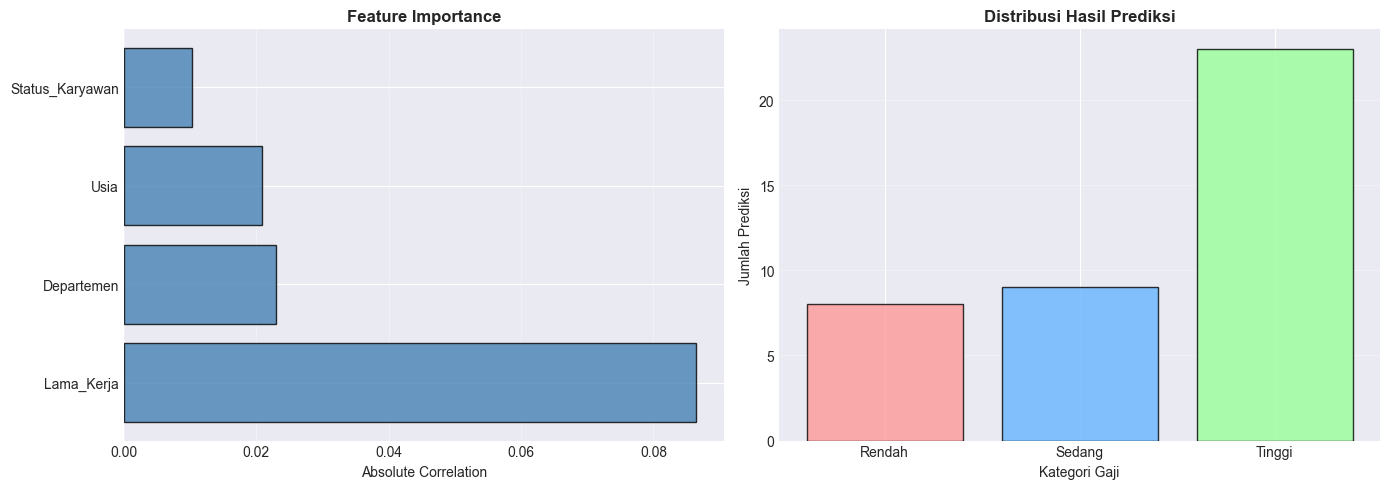

In [35]:
# Hitung korelasi fitur dengan target
X_with_target = X.copy()
y_encoded = LabelEncoder().fit_transform(y)
X_with_target['Target'] = y_encoded

correlations = X_with_target.corr()['Target'].drop('Target').abs().sort_values(ascending=False)

print("Feature Importance (Correlation with Target):")
for feature, corr in correlations.items():
    print(f"  {feature}: {corr:.4f}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
axes[0].barh(correlations.index, correlations.values, color='steelblue', alpha=0.8, edgecolor='black')
axes[0].set_xlabel('Absolute Correlation')
axes[0].set_title('Feature Importance', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Prediction distribution
pred_dist = pd.Series(y_pred).value_counts().sort_index()
axes[1].bar(pred_dist.index, pred_dist.values, color=['#ff9999', '#66b3ff', '#99ff99'], 
            alpha=0.8, edgecolor='black')
axes[1].set_xlabel('Kategori Gaji')
axes[1].set_ylabel('Jumlah Prediksi')
axes[1].set_title('Distribusi Hasil Prediksi', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## KESIMPULAN & ANALISIS

### Ringkasan Hasil

1. **Preprocessing Data:**
   - Handling missing values menggunakan mode untuk kategorikal dan median untuk numerik
   - Kategorisasi gaji menjadi 3 kelas (Rendah, Sedang, Tinggi) berdasarkan kuartil

2. **Model Performance:**
   - Akurasi model: [Lihat hasil di atas]
   - Precision, Recall, dan F1-Score menunjukkan performa model

3. **Feature Importance:**
   - Fitur yang paling berpengaruh dapat dilihat dari korelasi dengan target
   - Kombinasi fitur numerik dan kategorikal membentuk basis keputusan model

4. **Interpretasi Bisnis:**
   - Model dapat digunakan untuk prediksi kategori gaji karyawan baru
   - Probability dari setiap prediksi menunjukkan confidence level
   - Jika confidence rendah, perlu pertimbangan lebih lanjut dalam keputusan

### Rekomendasi untuk Peningkatan

1. **Tambah Fitur:**
   - Tingkat pendidikan (SMA/D3/S1/S2)
   - Sertifikasi profesional
   - Pengalaman kerja sebelumnya
   - Performa/rating karyawan

2. **Optimasi Model:**
   - Coba algoritma lain (Random Forest, SVM, Gradient Boosting)
   - Hyperparameter tuning
   - Cross-validation untuk evaluasi yang lebih robust

3. **Handling Class Imbalance:**
   - SMOTE oversampling jika ada kelas yang sangat imbalanced
   - Weighted class loss

### Kesimpulan

Naive Bayes Classification adalah algoritma yang sederhana namun powerful untuk problem klasifikasi. Dalam kasus prediksi gaji karyawan ini, model telah berhasil mendemonstrasikan konsep-konsep fundamental dari probabilistic classification. Meskipun asumsi independensi tidak selalu berlaku, Naive Bayes tetap memberikan hasil yang dapat digunakan sebagai baseline untuk comparison dengan algoritma yang lebih kompleks.